# Adding pre 2020 data

## Import Packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression

from prophet import Prophet
from pandas.tseries.holiday import USFederalHolidayCalendar
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric
from prophet.plot import add_changepoints_to_plot
import itertools

import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter('ignore', ConvergenceWarning)

import xgboost as xgb
from xgboost import plot_importance

## Import and Prepare the data

In [ ]:
# this is the time series split we will work with
tscv = TimeSeriesSplit(gap=0, max_train_size=None, n_splits=26, test_size=14)


# we import the data and clean it for future use
rs = pd.read_csv('../../scr/data/cleaned_rat_sightings_data/all_cleaned_rat_sightings.csv')
rs['created_date'] = pd.to_datetime(rs['created_date']) 
rs['closed_date'] = pd.to_datetime(rs['closed_date'])
rs['resolution_action_updated_date'] = pd.to_datetime(rs['resolution_action_updated_date'])
# mark cutoff dates, and also rename columns
rs = rs[rs['created_date']<'2026-03-01']
rs = rs[rs['created_date']>='2020-01-01']
rs = rs.groupby([rs['created_date'].dt.date]).size().reset_index(name='count')
rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)

rs2 = pd.read_csv('../../scr/data/cleaned_rat_sightings_data/cleaned_rat_sightings_pre2020.csv')
rs2['date'] = pd.to_datetime(rs2['date']) 
rs2 = rs2.groupby([rs2['date'].dt.date]).size().reset_index(name='count')
rs2.rename(columns={'date': 'ds', 'count': 'y'}, inplace=True)


rs = pd.concat([rs,rs2],ignore_index=True)
rs['ds'] = pd.to_datetime(rs['ds'])
rs = rs.sort_values(by='ds')


# this part fills in any days missing with y=0
rs['ds'] = pd.to_datetime(rs['ds'])
date_range = pd.date_range(start=rs['ds'].min(), end=rs['ds'].max(), freq='D')
rs_full = rs.set_index('ds').reindex(date_range, fill_value=0)
rs_full.reset_index(inplace=True)
rs_full.rename(columns={'index': 'ds'}, inplace=True)

rs

,ds,y
2251,2010-01-01,9
2252,2010-01-02,12
2253,2010-01-03,3
2254,2010-01-04,24
2255,2010-01-05,14
...,...,...
2246,2026-02-24,26
2247,2026-02-25,30
2248,2026-02-26,40
2249,2026-02-27,38


## Visualization

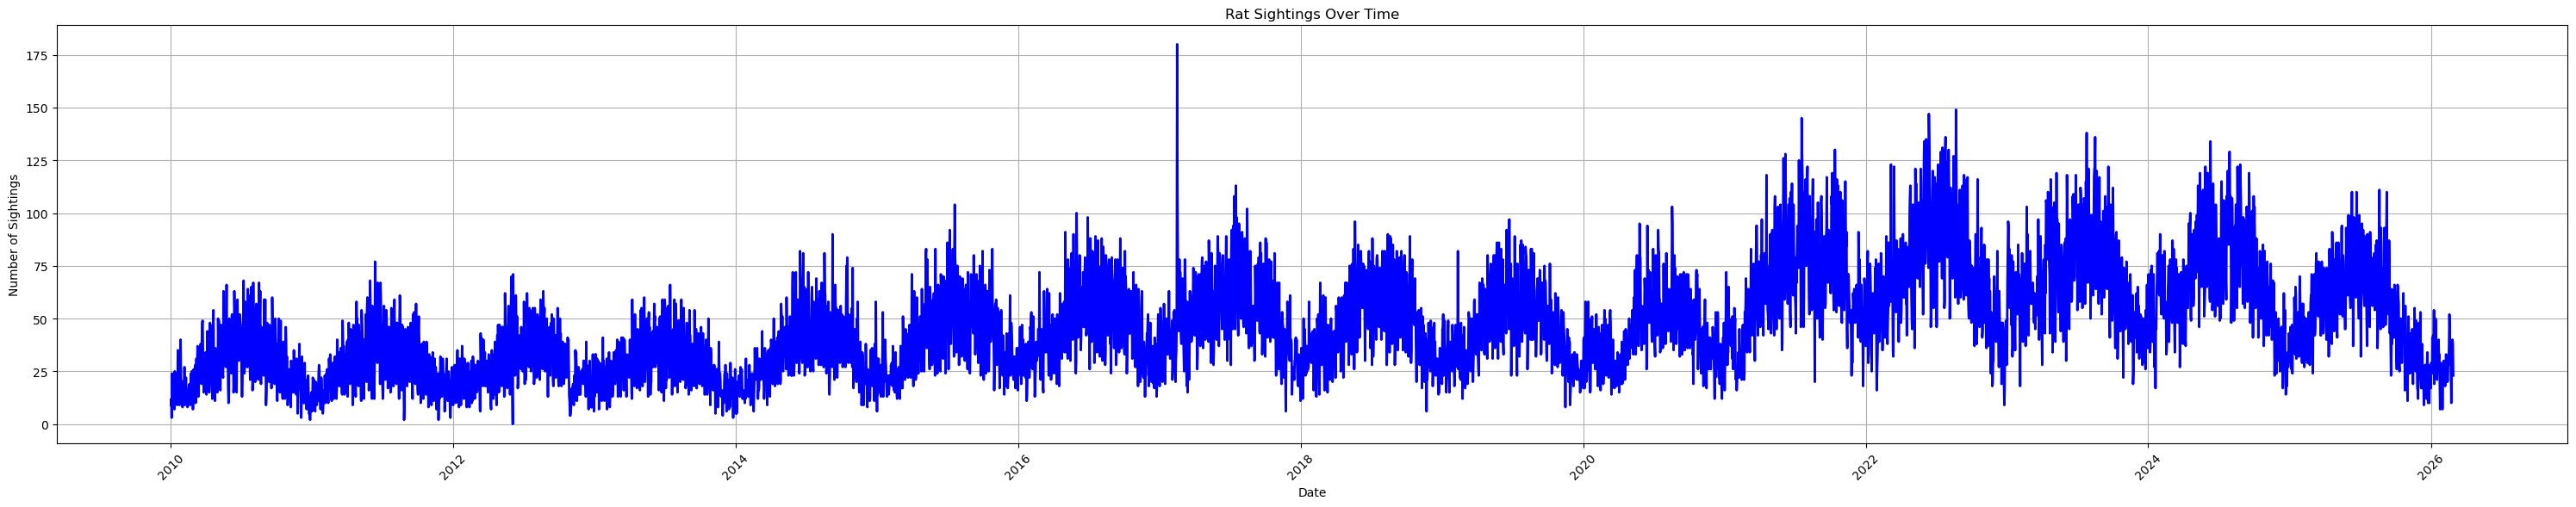

In [18]:
# Plotting the data
plt.figure(figsize=(30, 6)) 
plt.plot(rs_full['ds'], rs_full['y'], label='Rat Sightings', color='b', linewidth=2)

# Add labels and title
plt.xlabel('Date')
plt.ylabel('Number of Sightings')
plt.title('Rat Sightings Over Time')

# Rotate the x-axis labels for better readability
plt.xticks(rotation=45)

# Show a grid for better readability
plt.grid(True)

# Display the plot
plt.tight_layout()  # Adjust layout to avoid label clipping
plt.show()

In [19]:
# There's a pretty massive outlier there.
# Could be due to clerical issues.
rs[rs['y']>150]


,ds,y
4852,2017-02-15,180


# Prophet Forecasting

In [21]:
# this is the time series split we will work with
tscv = TimeSeriesSplit(gap=0, max_train_size=None, n_splits=26, test_size=14)


In [22]:
date_range = pd.date_range(start="2010-01-01", end="2026-02-28")

# Generate US federal holidays
calendar = USFederalHolidayCalendar()
holidays = calendar.holidays(start=date_range.min(), end=date_range.max())

federal_holidays = pd.DataFrame({
    'holiday': 'federal_us',
    'ds': pd.to_datetime(holidays),
    'lower_window': 0,
    'upper_window': 1})

holidays = federal_holidays

## Model Evaluation

We perform the exact same model evaluation process as before (see notebook 1models_citywide.ipynb). We wish to check to see if there is a significant improvement in the model's forecasting abilities.

Running this code, we see that we got a mean RMSE of 13.287273 over the 26 folds. The model got "worse".


In [23]:
# Rename columns for Prophet model
rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)
results = []

for i, (train_index, test_index) in enumerate(tscv.split(rs)):
    train = rs.iloc[train_index]
    test = rs.iloc[test_index]
    
    model = Prophet(holidays=holidays)
    model.add_country_holidays(country_name='US')

    model.fit(train)
    
    future = model.make_future_dataframe(periods=len(test), freq='D')
    forecast = model.predict(future)
    
    # Obtain predicted values and compare against the actuals.
    y_pred = forecast['yhat'][-len(test):].values
    y_true = test['y'].values
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    # Append results
    results.append({'fold': i, 'rmse': rmse, 'mape': mape})

prophet_results_df = pd.DataFrame(results)
prophet_results_df.loc['mean'] = ['mean',  prophet_results_df['rmse'].mean(), prophet_results_df['mape'].mean()]
prophet_results_df

20:35:04 - cmdstanpy - INFO - Chain [1] start processing
20:35:05 - cmdstanpy - INFO - Chain [1] done processing
20:35:06 - cmdstanpy - INFO - Chain [1] start processing
20:35:06 - cmdstanpy - INFO - Chain [1] done processing
20:35:07 - cmdstanpy - INFO - Chain [1] start processing
20:35:08 - cmdstanpy - INFO - Chain [1] done processing
20:35:09 - cmdstanpy - INFO - Chain [1] start processing
20:35:09 - cmdstanpy - INFO - Chain [1] done processing
20:35:10 - cmdstanpy - INFO - Chain [1] start processing
20:35:11 - cmdstanpy - INFO - Chain [1] done processing
20:35:12 - cmdstanpy - INFO - Chain [1] start processing
20:35:13 - cmdstanpy - INFO - Chain [1] done processing
20:35:14 - cmdstanpy - INFO - Chain [1] start processing
20:35:14 - cmdstanpy - INFO - Chain [1] done processing
20:35:15 - cmdstanpy - INFO - Chain [1] start processing
20:35:16 - cmdstanpy - INFO - Chain [1] done processing
20:35:17 - cmdstanpy - INFO - Chain [1] start processing
20:35:18 - cmdstanpy - INFO - Chain [1]

,fold,rmse,mape
0,0,12.214809,0.230941
1,1,8.130498,0.103554
2,2,7.727517,0.131515
3,3,10.046472,0.150568
4,4,10.322329,0.134620
5,5,13.941286,0.190198
6,6,10.988247,0.139556
7,7,12.769243,0.148290
8,8,10.858321,0.127764
9,9,7.901339,0.098074


# Neural Prophet Forecasting

In [24]:
from neuralprophet import NeuralProphet

import numpy as np
np.NaN = np.nan


# the following packages are meant to turn off a bunch of the warnings and ERRORs that pop up while running NeuralProphet.
# the errors that do show up are not all that important and a lot is due to outdated packages.
import warnings
import logging

warnings.filterwarnings("ignore")

logging.getLogger("neuralprophet").setLevel(logging.ERROR)
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)
logging.getLogger("NP").setLevel(logging.ERROR)

/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/lightning_fabric/__init__.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.


In [26]:
## Add weather data.

import requests
import pandas as pd

lat, lon = 40.7831, -73.9712
start = "2010-01-01"
end   = "2026-02-28"

url = (
    "https://archive-api.open-meteo.com/v1/archive"
    f"?latitude={lat}&longitude={lon}"
    f"&start_date={start}&end_date={end}"
    "&daily=temperature_2m_max,temperature_2m_min,temperature_2m_mean,"
    "apparent_temperature_max,apparent_temperature_min,apparent_temperature_mean,"
    "precipitation_sum,snowfall_sum"
    "&timezone=America/New_York"
)

response = requests.get(url)
data = response.json()

if 'error' in data:
    nd = pd.read_csv("weatherdata.csv")
    nd = nd.set_index('date')
    wd = nd
    
else:
    wd = pd.DataFrame(data["daily"])
    wd["date"] = pd.to_datetime(wd["time"])
    wd = wd.set_index("date")

def add_weather_data_no_index(df,wd):
    if "time" in wd.columns:
        wd = wd.drop(columns=["time"])

    for column in wd.columns:
        df[column] = wd[column].values

    return df

In [27]:
regressed_features = ['apparent_temperature_max', 
                      'apparent_temperature_min',
                    'snowfall_sum']
wd = wd.reset_index(drop=True).rename(columns={"time": "ds"})
wd["ds"] = pd.to_datetime(wd["ds"])
rs["ds"] = pd.to_datetime(rs["ds"])

rs = rs.merge(
    wd[['ds'] + regressed_features],
    on="ds",
    how="left"
)

In [30]:
lags_for_regressed_features = dict()
lags_for_regressed_features['apparent_temperature_max'] = 30
lags_for_regressed_features['apparent_temperature_min'] = 14
lags_for_regressed_features['snowfall_sum'] = 3

In [31]:
results = []

for i, (train_index, test_index) in enumerate(tscv.split(rs)):

    train = rs.iloc[train_index].copy()
    test = rs.iloc[test_index].copy()

    train = train.dropna(subset=["y"])


    model = NeuralProphet(yearly_seasonality=True, 
                          weekly_seasonality=True, 
                          epochs = 100,
                          accelerator = 'auto')

    model = model.add_country_holidays(country_name="US")

    for column in regressed_features:
        model.add_lagged_regressor(column, n_lags=lags_for_regressed_features[column])

    # merge regressors correctly
    # train = train.merge(wd[['ds'] + regressed_features], on="ds", how="left")

    model.fit(train, freq="D", progress="off")

    # build dataframe containing future regressors
    future = pd.concat([train[['ds','y'] + regressed_features], test[['ds','y']].merge(wd[['ds'] + regressed_features], on="ds", how="left")])
    forecast = model.predict(future)

    y_pred = forecast["yhat1"].iloc[-len(test):].values
    y_true = test["y"].values

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)

    results.append({"fold": i, "rmse": rmse, "mape": mape})

neural_prophet_results_df = pd.DataFrame(results)
neural_prophet_results_df.loc["mean"] = ["mean", neural_prophet_results_df["rmse"].mean(), neural_prophet_results_df["mape"].mean()]
neural_prophet_results_df

Finding best initial lr:   0%|          | 0/243 [00:00<?, ?it/s]

Training: 0it [00:00, ?it/s]

Predicting: 87it [00:00, ?it/s]

Finding best initial lr:   0%|          | 0/243 [00:00<?, ?it/s]

Training: 0it [00:00, ?it/s]

...

Predicting: 92it [00:00, ?it/s]

Finding best initial lr:   0%|          | 0/244 [00:00<?, ?it/s]

Training: 0it [00:00, ?it/s]

Predicting: 92it [00:00, ?it/s]

,fold,rmse,mape
0,0,13.633325,0.245302
1,1,8.088672,0.110996
2,2,11.988864,0.205777
3,3,12.572191,0.192558
4,4,14.205357,0.198392
5,5,18.892120,0.285717
6,6,13.950057,0.176563
7,7,11.875684,0.143383
8,8,12.593523,0.164190
9,9,13.567792,0.177619


After an 80 minute run, Neural Prophet gave the following table against our cross-validation scheme. It seems that we had no improvements upon adding more data.

fold	rmse	mape
0	0	13.633325	0.245302

1	1	8.088672	0.110996

2	2	11.988864	0.205777

3	3	12.572191	0.192558

4	4	14.205357	0.198392

5	5	18.892120	0.285717

6	6	13.950057	0.176563

7	7	11.875684	0.143383

8	8	12.593523	0.164190

9	9	13.567792	0.177619

10	10	14.384456	0.210303

11	11	17.661138	0.255597

12	12	12.483276	0.153321

13	13	11.408904	0.123418

14	14	24.445767	0.519114

15	15	15.814869	0.338632

16	16	22.596466	0.522207

17	17	23.417284	0.899346

18	18	16.372980	0.449799

19	19	12.043096	0.385413

20	20	15.084247	0.627189

21	21	16.166655	0.745061

22	22	10.722795	0.270335

23	23	13.507123	0.729170

24	24	15.893608	0.563176

25	25	12.742827	0.474462

mean	mean	14.850503	0.352578